In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_squared_error

#OBTENEMOS LOS DATOS DE 12 AÑOS
df = yf.download("^GSPC", start="2014-01-01", end="2026-01-01") 
#Nos quedamos solo con el primer nivel (Close, Open, etc.), elimino el ticker porque me va a dar problemas después
df.columns = df.columns.get_level_values(0)
df.columns.name = None
df.head()
#Observamos que hay días no incluidos. Estos días son fines de semana y festivos en los que el mercado está cerrado. 
#En proyectos de Machine Learning financiero no se usa el calendario natural, sino el de "Trading Days".
#Ahora tenemos 5 atributos y 3018 datos.
df = df.reset_index()
df.head()



[*********************100%***********************]  1 of 1 completed


,Date,Close,High,Low,Open,Volume
0,2014-01-02,1831.979980,1845.859985,1827.739990,1845.859985,3080600000
1,2014-01-03,1831.369995,1838.239990,1829.130005,1833.209961,2774270000
2,2014-01-06,1826.770020,1837.160034,1823.729980,1832.310059,3294850000
3,2014-01-07,1837.880005,1840.099976,1828.709961,1828.709961,3511750000
4,2014-01-08,1837.489990,1840.020020,1831.400024,1837.900024,3652140000


In [2]:
df.info() #Nos dice si hay valores nulos, el tipado de cada atributo, etc.
#Observamos que tenemos 3,018 entradas y exactamente 3,018 valores no nulos.
#Todos los atributos son numéricos.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3018 entries, 0 to 3017
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    3018 non-null   datetime64[ns]
 1   Close   3018 non-null   float64       
 2   High    3018 non-null   float64       
 3   Low     3018 non-null   float64       
 4   Open    3018 non-null   float64       
 5   Volume  3018 non-null   int64         
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 141.6 KB


In [3]:
df.describe()
#Muestra un resumen de la "distribución" de los datos:media, mediana, desviación típica...
#Observamos que los datos de volumen están en un rango de e+09, por lo que existe una diferencia de escala bastante grande. 
#El volumen es millones de veces más grande que el precio, por lo que necesitaremos aplicar Feature Scaling más adelante.
#Observamos además que VolumeMin = 0 y el S&P 500 nunca tiene volumen cero en un día de trading normal. 
#Probablemente corresponde a algún error en la descarga de yfinance o a un día festivo mal registrado.
#Por lo que hay que revisar estos días: si son errores, podemos eliminarlos o rellenarlos con la mediana.


,Date,Close,High,Low,Open,Volume
count,3018,3018.000000,3018.000000,3018.000000,3018.000000,3.018000e+03
mean,2019-12-30 16:40:33.399602688,3474.133077,3491.834877,3453.828727,3473.566942,4.043852e+09
min,2014-01-02 00:00:00,1741.890015,1755.790039,1737.920044,1743.819946,0.000000e+00
25%,2016-12-29 06:00:00,2264.137512,2271.837524,2258.259949,2267.052551,3.406532e+09
50%,2019-12-30 12:00:00,3004.280029,3016.190063,2989.734985,3004.170044,3.835995e+09
75%,2022-12-27 18:00:00,4379.797363,4409.619995,4356.070068,4380.849976,4.466820e+09
max,2025-12-31 00:00:00,6932.049805,6945.770020,6921.600098,6936.020020,9.976520e+09
std,NaN,1353.254009,1359.846068,1345.706021,1353.046445,1.006061e+09


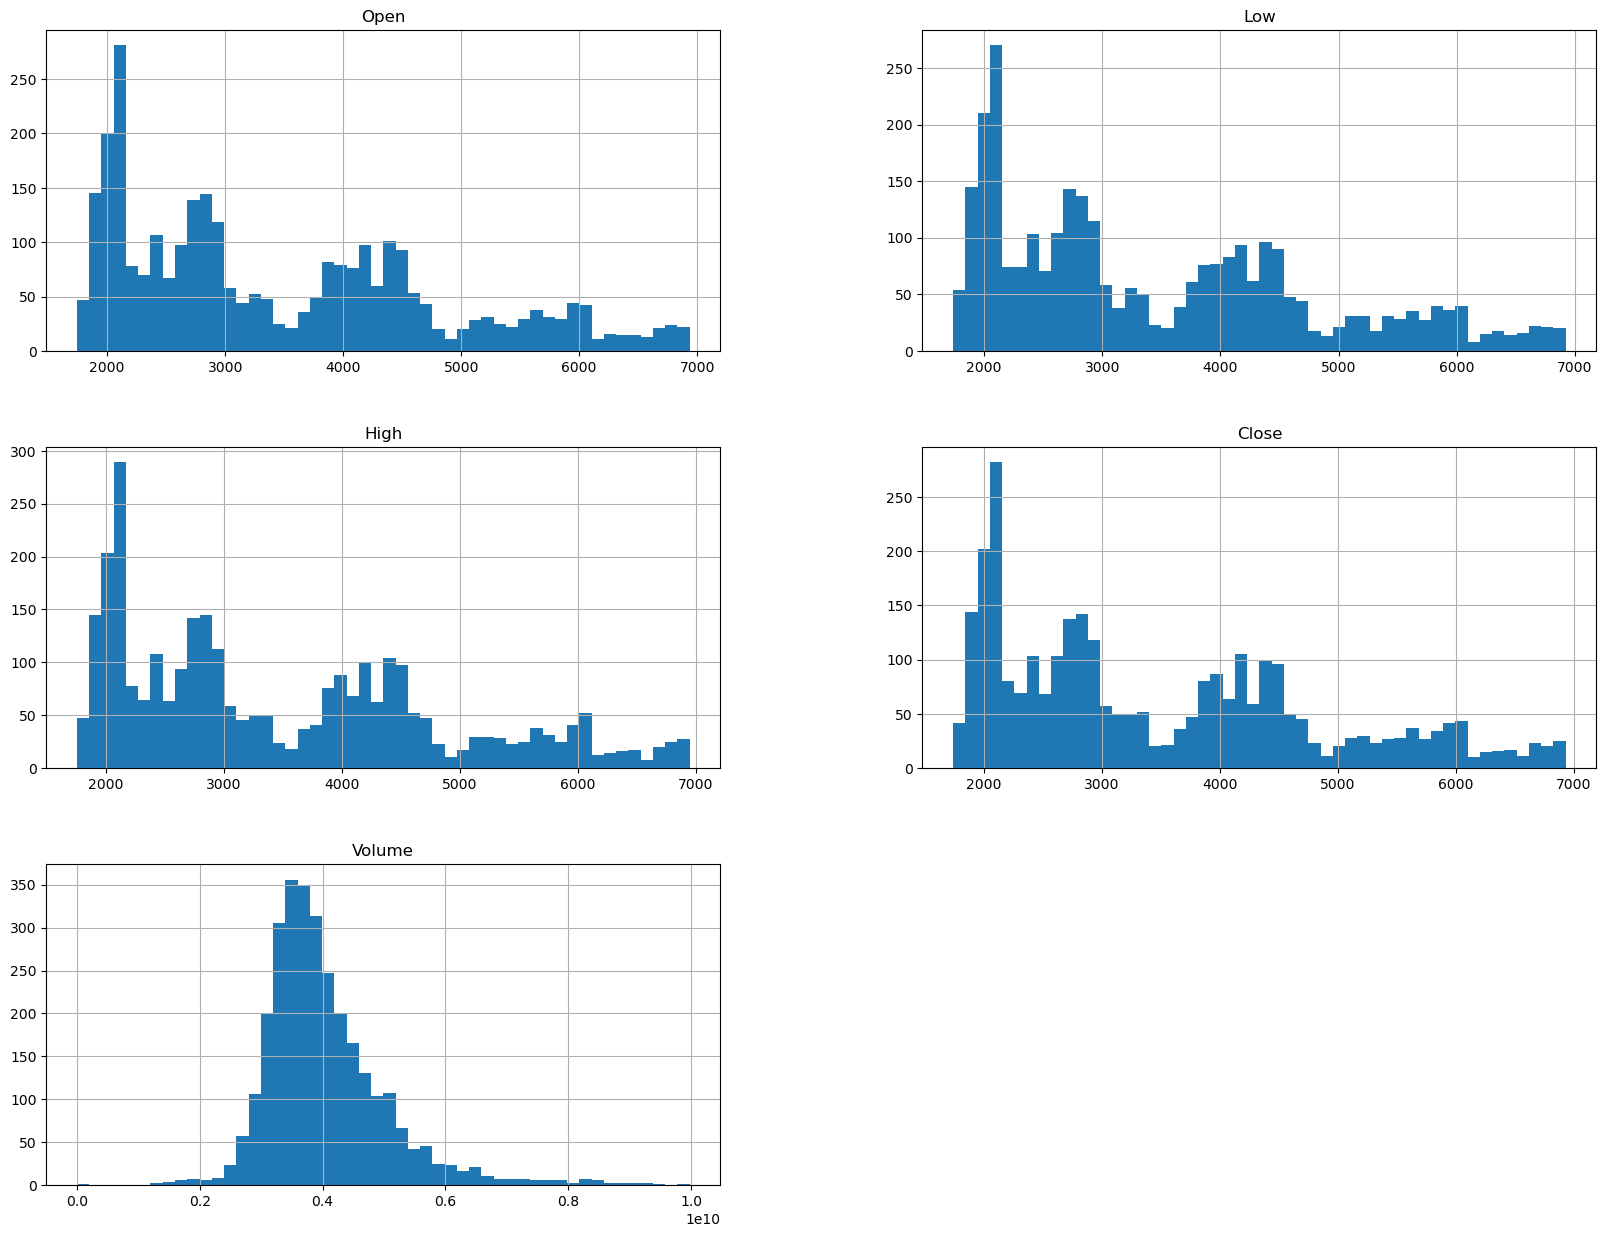

In [4]:
#Hacemos histogramas: muestran el número de ejemplos (eje Y) que devuelven el valor en un determinado rango (eje X)
import matplotlib.pyplot as plt
%matplotlib inline
df[['Open', 'Low', 'High', 'Close', 'Volume']].hist(bins=50, figsize=(20,15))
plt.show()
#Volvemos a notar el problema de la escala en volumen
#Además la variable volumen tiene la cola derecha más pesada (desde la mediana)
#Sin embargo, los precios (Close, Open, etc.) ocupan casi todo el gráfico, pero el volumen está muy concentrado a la izquierda con una "cola" larga.


In [5]:
#Vamos a analizar el problema de ese 0 en la variable volumen (el volumen 0 no existe en días de mercado abierto).
#Buscamos qué días tienen volumen 0
dias_con_vol0 = df[df['Volume'] == 0]
print(dias_con_vol0)
#Ese 24 de mayo de 2023 fue un miércoles normal de mercado; el S&P 500 operó con normalidad.
#Por tato un 0 ahí es un error de pérdida de datos en la descarga.
#Vamos a sustituirlo por la mediana:

           Date        Close         High         Low         Open  Volume
2364 2023-05-24  4115.240234  4132.959961  4103.97998  4132.959961       0


In [6]:
median_volume = df[df['Volume'] > 0]['Volume'].median()
df.loc[df['Volume'] == 0, 'Volume'] = median_volume
#Efectivamente ahora ya no hay ningún día con volumen 0.

In [ ]:
#Empezamos con la regresión lineal:
#-Variable respuesta: Close(t), Close(t+1),... (la respuesta va a ser múltiple)
#-Variables predictoras: Open(t-1), Close(t-1), Volume(t-1), High/Low(t-1) y estas mismas hasta (t-30) (30x5 predictoras).
#Tenemos que hacerlo así porque si estamos intentando predecir close(t), del día t no conocemos nada. Para esto, hay que entrenar en paralelo 5 modelos, uno para cada predictora, ya que
#si quiero close(t+1) tengo que usar un modelo que incluya las predicciones close(t), open(t)...
#Como estas son predicciones, el error va a ser acumulativo. Esto lo hago hasta t+k y debería ver que el error va creciendo cuanto más me alejo porque se acumula.
#Ahora vamos a entrenar 5 modelos en paralelo: 

In [7]:
#Escogemos la ventana de tiempo:
tiempo=30
#Creo las predictoras:
X_cols=[]
for i in range(1,tiempo+1):
    for col in ['Open','Close','High','Low','Volume']:
        name=f"{col}(t-{i})"
        df[name]=df[col].shift(i)
        X_cols.append(name)

y_cols = ['Open','Close','High','Low','Volume']


/var/folders/0w/h7lsgh5d2kxblpdfhxyvt0vw0000gn/T/ipykernel_22745/3798430063.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[name]=df[col].shift(i)
/var/folders/0w/h7lsgh5d2kxblpdfhxyvt0vw0000gn/T/ipykernel_22745/3798430063.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[name]=df[col].shift(i)
/var/folders/0w/h7lsgh5d2kxblpdfhxyvt0vw0000gn/T/ipykernel_22745/3798430063.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance

In [8]:
#Evidentemente el shift de 30 días hace que los primeros 30 valores sean NaNs, por lo que hay que eliminarlos.
df_nuevo = df.dropna()
#Voy a hacer una copia para no sobreescribir:
df_model = df_nuevo.copy()
df_model.head()
#Ya tengo los datos listos para el entrenamiento.

,Date,Close,High,Low,Open,Volume,Open(t-1),Close(t-1),High(t-1),Low(t-1),...,Open(t-29),Close(t-29),High(t-29),Low(t-29),Volume(t-29),Open(t-30),Close(t-30),High(t-30),Low(t-30),Volume(t-30)
30,2014-02-14,1838.630005,1841.650024,1825.589966,1828.459961,3114750000,1814.819946,1829.829956,1830.250000,1809.219971,...,1833.209961,1831.369995,1838.239990,1829.130005,2.774270e+09,1845.859985,1831.979980,1845.859985,1827.739990,3.080600e+09
31,2014-02-18,1840.760010,1842.869995,1835.010010,1839.030029,3421110000,1828.459961,1838.630005,1841.650024,1825.589966,...,1832.310059,1826.770020,1837.160034,1823.729980,3.294850e+09,1833.209961,1831.369995,1838.239990,1829.130005,2.774270e+09
32,2014-02-19,1828.750000,1847.500000,1826.989990,1838.900024,3661570000,1839.030029,1840.760010,1842.869995,1835.010010,...,1828.709961,1837.880005,1840.099976,1828.709961,3.511750e+09,1832.310059,1826.770020,1837.160034,1823.729980,3.294850e+09
33,2014-02-20,1839.780029,1842.790039,1824.579956,1829.239990,3404980000,1838.900024,1828.750000,1847.500000,1826.989990,...,1837.900024,1837.489990,1840.020020,1831.400024,3.652140e+09,1828.709961,1837.880005,1840.099976,1828.709961,3.511750e+09
34,2014-02-21,1836.250000,1846.130005,1835.599976,1841.069946,3403880000,1829.239990,1839.780029,1842.790039,1824.579956,...,1839.000000,1838.130005,1843.229980,1830.380005,3.581150e+09,1837.900024,1837.489990,1840.020020,1831.400024,3.652140e+09


In [9]:
#Ahora vamos a generar el training set y el test set (el test set solo lo vamos a usar al final para comparar con las predicciones)
#Como queremos una división cronológica no podemos mezclar los datos:
modelo_copia=df_model.copy()
train_m=modelo_copia.iloc[:-tiempo] #todo menos los últimos 30 días
test_m =modelo_copia.iloc[-tiempo:] #solo los últimos 30 días

In [10]:
X_train = train_m[X_cols]
y_train = train_m[y_cols]

X_test = test_m[X_cols]
y_test = test_m[y_cols]
#Hacemos esto porque los pasos de limpieza siguientes (como escalar) se aplican solo a los atributos. Además así lo tenemos preparado para el algoritmo de regresión.
#X_test e y_test no se pueden usar porque son datos que aparentemente no conocemos, solo conocemos los datos de entrenamiento.



In [11]:
#No teníamos datos faltantes ni variables categóricas, por lo que el mayor problema que nos queda por solucionar
#es la escala de algunas variables. El escalado hace que el algoritmo trate a todas las variables con la misma justicia,
#si no, por ejemplo Volumen, tendría mucha más fuerza en el modelo (por moverse en una escala mayor).
#Usaremos la estandarización:
from sklearn.preprocessing import StandardScaler
scaler_x = StandardScaler()
X_train_scaled = scaler_x.fit_transform(X_train)
X_test_scaled = scaler_x.transform(X_test)

In [12]:
#ENTRENAMIENTO
model = MultiOutputRegressor(LinearRegression())
model.fit(X_train_scaled, y_train)

,estimator,LinearRegression()
,n_jobs,None
,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [13]:
#Medimos el error de Close en el conjunto de entrenamiento
sp500_predictions = model.predict(X_train_scaled)
predicc = pd.DataFrame(sp500_predictions, columns=y_cols)
mse = mean_squared_error(y_train['Close'], predicc['Close'])
rmse = np.sqrt(mse)
print(f"Error Regresión Lineal Entrenamiento Close: {rmse}")
#Es un error de 36 aproximadamente, y como Close esta entre 1700 y 7000 aprox, un error de 36 es bastante bueno.
#Esto es normal si evaluamos el error en el Train Set.


Error Regresión Lineal Entrenamiento Close: 36.780687436096464


In [14]:
#EXPERIMENTO: PREDICCIÓN RECURSIVA (30 últimos días a ciegas)
ventana_recursiva = X_test_scaled[0].reshape(1, -1) #El primer día (hoy) sí tiene los datos de los 30 anteriores
preds_recursivas = []

for i in range(tiempo):
    # Predicción del día t 
    pred_t= model.predict(ventana_recursiva)
    preds_recursivas.append(pred_t[0])
    
    #Actualizamos la ventana para el día t+1
    #Recuperamos los datos originales de la ventana actual (30 días x 5 variables)
    lags_actuales = scaler_x.inverse_transform(ventana_recursiva).reshape(tiempo, 5)

    #Desplazamos: la predicción de hoy entra como el nuevo "t-1"
    #El t-1 antiguo pasa a ser t-2, y el t-30 desaparece.
    nuevos_lags = np.vstack([pred_t, lags_actuales[:-1]])
    
    #Escalamos de nuevo para la siguiente entrada del modelo
    ventana_recursiva = scaler_x.transform(nuevos_lags.flatten().reshape(1, -1))

#Lo pongo todo en un dataframe
df_preds_rec = pd.DataFrame(preds_recursivas, columns=y_cols)

/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/

In [16]:
#Ahora veamos el RMSE en los últimos 30 días (error acumulativo)
#Comparamos los datos reales (y_test) con los recursivos (df_preds_rec)
#Ambos tienen 30 filas y 5 columnas (Open, Close, High, Low, Volume)
precios_reales = y_test['Close'].values
precios_recursivos = df_preds_rec['Close'].values
errores_absolutos = []
for i in range(tiempo):
    abs_error=abs(precios_reales[i]-precios_recursivos[i])
    errores_absolutos.append(abs_error)
    print(f"El error el día {i} es: {abs_error}")

El error el día 0 es: 60.34164516686906
El error el día 1 es: 53.14630242714247
El error el día 2 es: 138.14735661613122
El error el día 3 es: 99.7340844323844
El error el día 4 es: 15.091587133736539
El error el día 5 es: 76.26812743225855
El error el día 6 es: 128.71867960966665
El error el día 7 es: 152.57809532466672
El error el día 8 es: 93.85907785910604
El error el día 9 es: 116.94868497355492
El error el día 10 es: 149.7511108986564
El error el día 11 es: 184.80535827259155
El error el día 12 es: 190.49922234866062
El error el día 13 es: 167.60311088489107
El error el día 14 es: 161.5191788562788
El error el día 15 es: 186.7134842664491
El error el día 16 es: 172.47757171978083
El error el día 17 es: 105.07229780757007
El error el día 18 es: 95.19218241356612
El error el día 19 es: 72.92803437428302
El error el día 20 es: 7.870822491942818
El error el día 21 es: 53.40547800509012
El error el día 22 es: 111.78912359018886
El error el día 23 es: 136.28237601395813
El error el día

In [17]:
#Cálculo del RMSE FINAL de los 30 días
mse_final = mean_squared_error(precios_reales, precios_recursivos)
rmse_final = np.sqrt(mse_final)

print(f"RMSE TOTAL del periodo ({tiempo} días): {rmse_final:.2f}")

RMSE TOTAL del periodo (30 días): 125.53


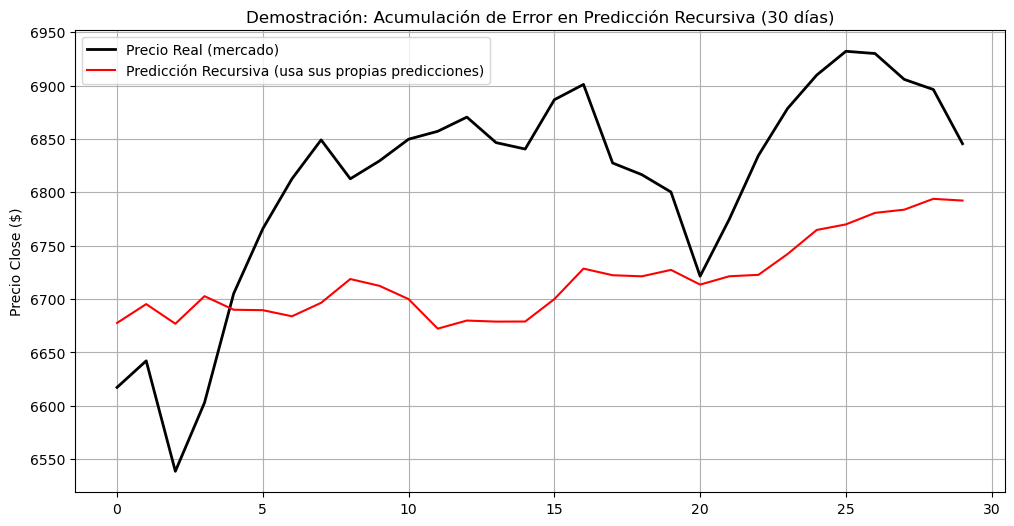

In [18]:
#Veamos el error (se ha ido acumulando pues cada vez hemos usado más predicciones)
plt.figure(figsize=(12, 6))
plt.plot(precios_reales, label='Precio Real (mercado)', color='black', linewidth=2)
plt.plot(precios_recursivos, label='Predicción Recursiva (usa sus propias predicciones)', color='red')
plt.title(f"Demostración: Acumulación de Error en Predicción Recursiva ({tiempo} días)")
plt.ylabel('Precio Close ($)')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
#La principal conclusión es que el modelo sufre de propagación de error: al utilizar una predicción (que ya contiene un pequeño error) como dato de entrada para la siguiente, el modelo deja de predecir el mercado real.
#De hecho si aumentamos la ventana de tiempo de 30 días a 60 o 90 el error crece significativamente.
#Un error de 125 sobre un índice de 5.000 es un 2.5%, que aparentemente es poco. 
#Sin embargo, como hemos estado intentando predecir el día a día, un 2.5% es mucho teniendo en cuenta que el S&P 500 suele moverse entre un 0.5% y un 1% en un día normal.